# Web Scraping and Analysis of Job Postings

## Project Overview
This project demonstrates web scraping using Python to extract job postings 
from a publicly available website. The data is cleaned and analyzed to 
identify the most in-demand job roles and skills.

## Tools Used
- Python
- Requests
- BeautifulSoup
- Pandas
- Matplotlib

---

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

## Data Collection

The data is scraped from:
https://realpython.github.io/fake-jobs/

This website is publicly available and designed for scraping practice.
The following fields are extracted:
- Job Title
- Company Name
- Location
- Posted Date

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://realpython.github.io/fake-jobs/"
response = requests.get(url)

soup = BeautifulSoup(response.text, "lxml")

jobs = soup.find_all("div", class_="card-content")

data = []

for job in jobs:
    title = job.find("h2", class_="title").text.strip()
    company = job.find("h3", class_="company").text.strip()
    location = job.find("p", class_="location").text.strip()
    date = job.find("time").text.strip()

    data.append([title, company, location, date])

df = pd.DataFrame(data, columns=["Title", "Company", "Location", "Date"])
df.to_csv("jobs.csv", index=False)

print(df.head())

                     Title                     Company              Location  \
0  Senior Python Developer    Payne, Roberts and Davis       Stewartbury, AA   
1          Energy engineer            Vasquez-Davidson  Christopherville, AA   
2          Legal executive  Jackson, Chambers and Levy   Port Ericaburgh, AA   
3   Fitness centre manager              Savage-Bradley     East Seanview, AP   
4          Product manager                 Ramirez Inc   North Jamieview, AP   

         Date  
0  2021-04-08  
1  2021-04-08  
2  2021-04-08  
3  2021-04-08  
4  2021-04-08  


In [3]:
df.to_csv("jobs_data.csv", index=False)

## Data Cleaning

- Removed duplicate entries
- Standardized text formatting
- Checked for missing values

In [4]:
df.drop_duplicates(inplace=True)
df['Title'] = df['Title'].str.strip()
df['Company'] = df['Company'].str.strip()
df['Location'] = df['Location'].str.strip()
df['Date'] = df['Date'].str.strip()


## Exploratory Data Analysis

This section analyzes:
- Most frequent job titles
- Common role keywords

Title
Python Programmer (Entry-Level)            3
Legal executive                            2
Materials engineer                         2
Software Developer (Python)                2
Manufacturing systems engineer             2
Back-End Web Developer (Python, Django)    2
Futures trader                             2
Textile designer                           1
Product manager                            1
Medical technical officer                  1
Name: count, dtype: int64


<Axes: xlabel='Title'>

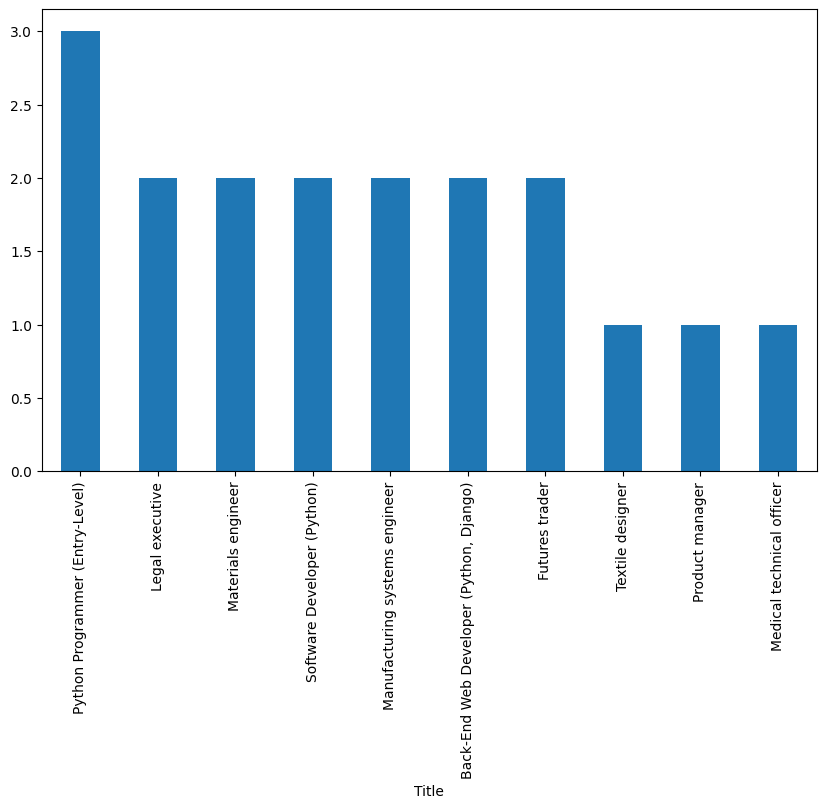

In [5]:
title_counts = df['Title'].value_counts()
print(title_counts.head(10))
plt.figure(figsize=(10, 6))
title_counts.head(10).plot(kind='bar')  

## Skills analysis


{'Python': np.int64(10), 'manager': np.int64(5), 'engineer': np.int64(11), 'developer': np.int64(7), 'data': np.int64(2), 'analyst': np.int64(0)}


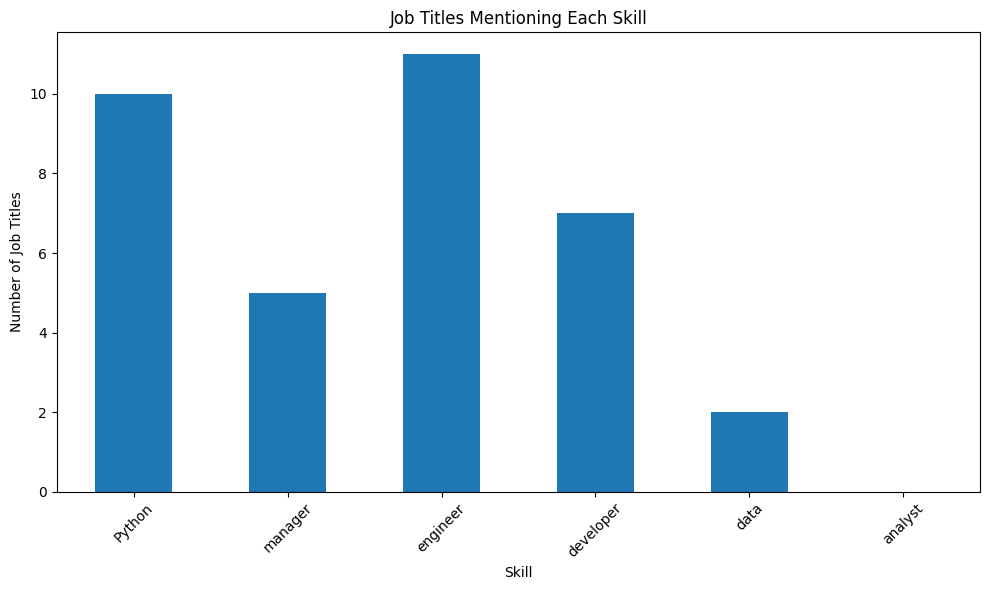

In [7]:
skills = ["Python", "manager", "engineer", "developer", "data", "analyst"]
skill_counts = {}
for skill in skills:
    skill_counts[skill] = df['Title'].str.contains(skill, case=False).sum()
print(skill_counts)
plt.figure(figsize=(10, 6))
pd.Series(skill_counts).plot(kind='bar')
plt.title("Job Titles Mentioning Each Skill")
plt.xlabel("Skill")
plt.ylabel("Number of Job Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Visualizion 


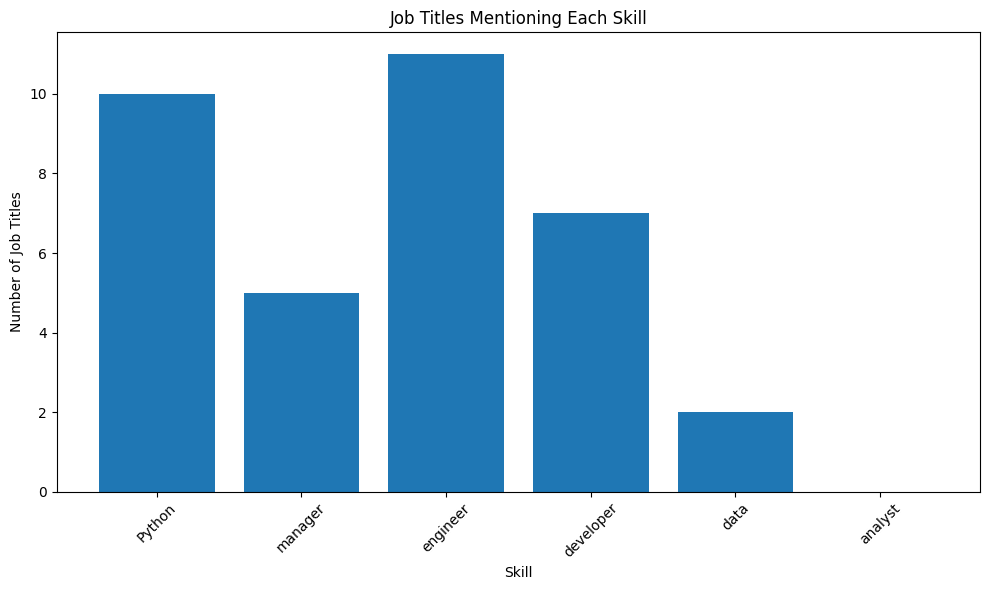

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(skill_counts.keys(), skill_counts.values())
plt.title("Job Titles Mentioning Each Skill")
plt.xticks(rotation=45)
plt.xlabel("Skill")
plt.ylabel("Number of Job Titles")
plt.tight_layout()
plt.show()



## Conclusion

This project demonstrates a complete end-to-end workflow of web data extraction and analytical processing using Python. Job posting data was systematically collected from a publicly accessible website using the Requests and BeautifulSoup libraries. The extracted information was structured into a Pandas DataFrame, followed by data cleaning and preprocessing to ensure consistency and accuracy.

Through exploratory analysis, patterns in job titles and keyword frequency were identified. Roles containing terms such as "Developer", "Engineer", and "Manager" appeared prominently, suggesting a strong emphasis on technical expertise and managerial capabilities within the dataset. The keyword-based analysis further highlighted the demand for analytical and programming-related roles, reflecting broader industry trends in technology-driven job markets.

Data visualization techniques were applied to enhance interpretability and provide a clearer representation of the findings. The graphical insights support the analytical observations and demonstrate the importance of visual communication in data-driven decision-making.

Overall, this project reflects practical competencies in web scraping, data preprocessing, exploratory data analysis, and visualization. It illustrates how raw web-based information can be transformed into structured, actionable insights. The methodology implemented here can be extended to larger, real-world datasets (where scraping policies permit) to analyze hiring trends, skill demand, and evolving job market dynamics at scale.